### Load libraries and data

In [1]:
import pandas as pd
import numpy as np
import warnings
import geopandas as gpd

warnings.filterwarnings('ignore')

/Users/jonzimmerman/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
url1 = "https://raw.githubusercontent.com/statzenthusiast921/wildfires/refs/heads/main/data/fire_df_wa.csv"
url2 = "https://raw.githubusercontent.com/statzenthusiast921/wildfires/refs/heads/main/data/fire_df_or.csv"
url3 = "https://raw.githubusercontent.com/statzenthusiast921/wildfires/refs/heads/main/data/fire_df_ca.csv"

df_wa = pd.read_csv(url1)
df_or = pd.read_csv(url2)
df_ca = pd.read_csv(url3, dtype={16: str, 18: str})

In [3]:
df = pd.concat([df_wa, df_or, df_ca], ignore_index=True)
df.shape

(284151, 19)

### Clean up data

In [4]:
df['EndDate'] = pd.to_datetime(df['CONT_DATE'], unit='D', origin='julian')
df['StartDate'] = pd.to_datetime(df['DISCOVERY_DATE'], unit='D', origin='julian')
df['FireLengthDays'] = df['CONT_DATE'] - df['DISCOVERY_DATE']

In [5]:
df.head()

,NWCG_REPORTING_UNIT_NAME,FIRE_NAME,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,DISCOVERY_TIME,STAT_CAUSE_CODE,STAT_CAUSE_DESCR,CONT_DATE,CONT_DOY,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,STATE,COUNTY,FIPS_CODE,FIPS_NAME,EndDate,StartDate,FireLengthDays
0,Umatilla National Forest,UPPER JIM,2005,2453540.5,170,1430.0,1.0,Lightning,2453541.5,171.0,...,B,46.220833,-117.785000,WA,27,27.0,Grays Harbor,2005-06-20,2005-06-19,1.0
1,Umatilla National Forest,SKYLINE,2005,2453567.5,197,1354.0,4.0,Campfire,2453567.5,197.0,...,A,46.080556,-117.890833,WA,13,13.0,Columbia,2005-07-16,2005-07-16,0.0
2,Columbia River Gorge National Scenic Area,MP 80,2005,2453516.5,146,950.0,6.0,Railroad,2453516.5,146.0,...,A,45.665000,-121.203611,WA,39,39.0,Klickitat,2005-05-26,2005-05-26,0.0
3,Idaho Panhandle National Forest,BUTCH CREEK,2005,2453585.5,215,1236.0,9.0,Miscellaneous,2453585.5,215.0,...,A,48.356667,-117.060833,WA,51,51.0,Pend Oreille,2005-08-03,2005-08-03,0.0
4,Columbia River Gorge National Scenic Area,LOCKE LAKE,2005,2453555.5,185,2002.0,6.0,Railroad,2453555.5,185.0,...,A,45.699444,-121.413611,WA,39,39.0,Klickitat,2005-07-04,2005-07-04,0.0


In [6]:
prefix_map = {"WA": "53", "CA": "06", "OR": "41"}

def make_fips(row):
    if pd.isna(row["FIPS_CODE"]):
        return np.nan
    
    county_code = str(int(row["FIPS_CODE"])).zfill(3)
    state_prefix = prefix_map.get(row["STATE"], "")
    
    return state_prefix + county_code if state_prefix else np.nan

df["FIPS"] = df.apply(make_fips, axis=1)

In [7]:
df["FIPS_length"] = df["FIPS"].astype(str).str.len()
df["FIPS_length"].value_counts()

FIPS_length
3    164516
5    119635
Name: count, dtype: int64

In [8]:
df_good = df[df['FIPS_length']==5]
df_bad = df[df['FIPS_length']==3]

### Get the FIPS code by using the lat/long coords

In [9]:
from shapely.geometry import Point
counties = gpd.read_file("/Users/jonzimmerman/Desktop/Data Projects/Wildfires/data/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
counties = counties[counties['STATEFP'].isin(['06','41','53'])]  # CA=06, OR=41, WA=53
counties = counties[['STATEFP', 'COUNTYFP', 'GEOID', 'geometry']]  # GEOID is full FIPS

# 2. Convert your df to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_bad,
    geometry=gpd.points_from_xy(df_bad["LONGITUDE"], df_bad["LATITUDE"]),
    crs="EPSG:4326"
)

# 3. Spatial join
gdf = gpd.sjoin(gdf, counties, how="left", predicate="within")

# 4. Fill missing FIPS with GEOID from join
gdf["FIPS"] = gdf["FIPS"].fillna(gdf["GEOID"])

# 5. Drop geometry columns if you want back a regular DataFrame
df_bad = pd.DataFrame(gdf.drop(columns=['geometry', 'index_right', 'STATEFP', 'COUNTYFP', 'GEOID']))


In [10]:
df_all = pd.concat([df_bad, df_good], ignore_index=True)

In [11]:
#Recalculate
df_all["FIPS_length"] = df_all["FIPS"].astype(str).str.len()
df_all["FIPS_length"].value_counts()

FIPS_length
5    283906
3       245
Name: count, dtype: int64

In [12]:
df_all = df_all[df_all['FIPS_length']==5]

In [13]:
df_all.groupby("STATE")["FIPS"].nunique().reset_index()

,STATE,FIPS
0,CA,60
1,OR,41
2,WA,43


### Let's do count of fires by day - might be more fruitful

In [28]:
df_model = df_all[['FIPS','StartDate','STAT_CAUSE_DESCR','FIRE_SIZE','FireLengthDays']]
df_model.head()

,FIPS,StartDate,STAT_CAUSE_DESCR,FIRE_SIZE,FireLengthDays
0,53059,2006-06-17,Miscellaneous,0.1,0.0
1,53051,1992-06-04,Lightning,0.1,0.0
2,53051,1992-06-26,Lightning,0.1,0.0
3,53051,1992-06-26,Lightning,0.1,0.0
4,53051,1992-06-26,Lightning,0.1,0.0


In [15]:
df_model['StartDate'].max()

Timestamp('2015-12-31 00:00:00')

### Count fires by cause and date

In [16]:
counts = (
    df_model
    .groupby(['FIPS', 'StartDate', 'STAT_CAUSE_DESCR'])
    .size()
    .reset_index(name='FireCount')
)

In [17]:
pivoted = counts.pivot_table(
    index=['FIPS', 'StartDate'],
    columns='STAT_CAUSE_DESCR',
    values='FireCount',
    fill_value=0
).reset_index()

### Impute 0 for days with no fires

In [18]:
print('# of rows before imputation: ',pivoted.shape[0])
df_model['StartDate'] = pd.to_datetime(df_model['StartDate'])
max_date_for_all_fips = pd.Timestamp('2015-12-31')

out = []
for fips, g in pivoted.groupby('FIPS'):
    # full date range for this FIPS
    idx = pd.date_range(g['StartDate'].min(), max_date_for_all_fips, freq='D')
    g = g.set_index('StartDate').reindex(idx, fill_value=0)
    g['FIPS'] = fips
    g = g.rename_axis('StartDate').reset_index()
    g.columns.name = None
    out.append(g)

full = pd.concat(out, ignore_index=True)
full.columns.name = None
print('# of rows after imputation: ',full.shape[0])

# of rows before imputation:  154472
# of rows after imputation:  1154622


In [19]:
full["MonthStart"] = pd.to_datetime(full["StartDate"]).dt.to_period("M").dt.to_timestamp()
full = (
    full
    .groupby(['FIPS', 'MonthStart'], as_index=False)
    .agg({
        'Arson': 'sum',
        'Campfire': 'sum',
        'Children': 'sum',
        'Debris Burning': 'sum',
        'Equipment Use': 'sum',
        'Fireworks': 'sum',
        'Lightning': 'sum',
        'Miscellaneous': 'sum',
        'Missing/Undefined': 'sum',
        'Powerline': 'sum',
        'Railroad': 'sum',
        'Smoking': 'sum',
        'Structure': 'sum'
    })
)
full['Accidental_Recreation'] = full['Campfire'] + full['Children'] + full['Fireworks'] + full['Smoking']
full['Accidental_LandMgmt'] = full['Debris Burning'] + full['Structure'] 
full['Accidental_Infra'] = full['Equipment Use'] + full['Powerline'] + full['Railroad'] 
full['Misc'] = full['Miscellaneous'] + full['Missing/Undefined']
full['TotalFires'] = full['Arson'] + full['Lightning'] + full['Accidental_Recreation'] + \
                     full['Accidental_LandMgmt'] + full['Accidental_Infra'] + full['Misc']

full = full.drop(['Campfire', 'Children', 'Fireworks','Smoking',
                 'Debris Burning','Structure',
                 'Equipment Use','Powerline','Railroad',
                 'Miscellaneous','Missing/Undefined'], axis=1)

full.head()

,FIPS,MonthStart,Arson,Lightning,Accidental_Recreation,Accidental_LandMgmt,Accidental_Infra,Misc,TotalFires
0,06001,1992-05-01,0.0,0.0,0.0,0.0,4.0,0.0,4.0
1,06001,1992-06-01,1.0,0.0,2.0,0.0,8.0,5.0,16.0
2,06001,1992-07-01,0.0,0.0,0.0,0.0,11.0,6.0,17.0
3,06001,1992-08-01,1.0,0.0,2.0,0.0,2.0,2.0,7.0
4,06001,1992-09-01,0.0,0.0,1.0,0.0,4.0,3.0,8.0


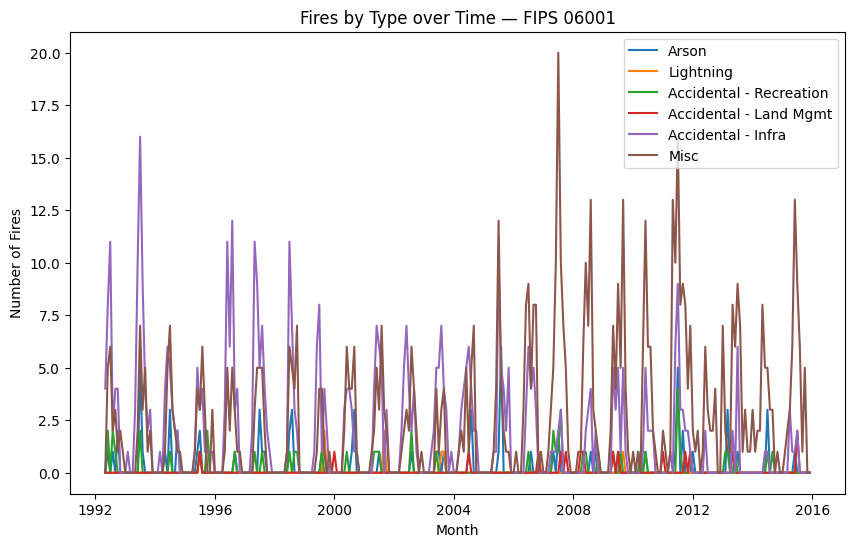

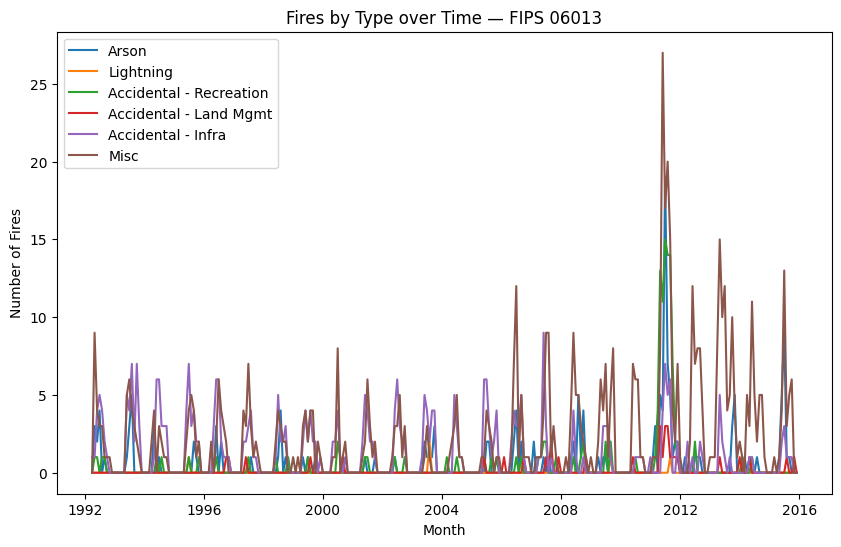

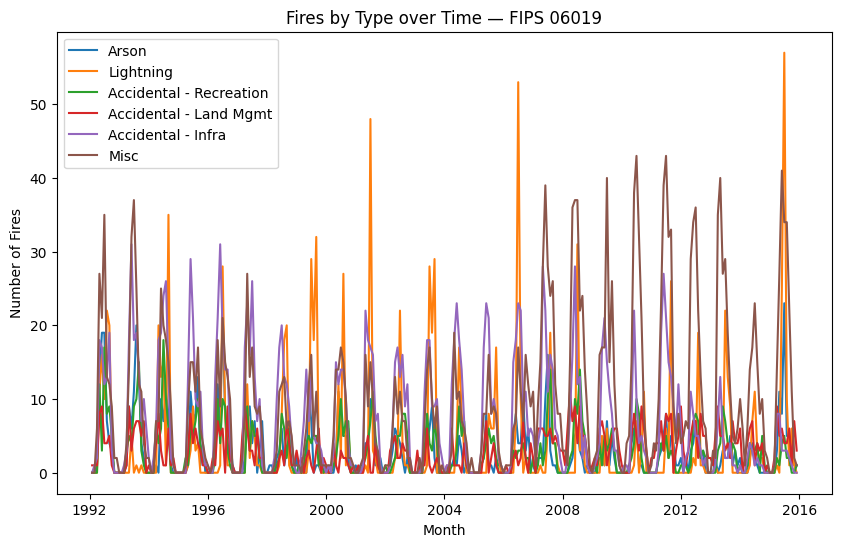

In [20]:
import matplotlib.pyplot as plt

fips_list = ['06001', '06013', '06019']  

for f in fips_list:
    subset = full[full['FIPS'] == f]
    
    plt.figure(figsize=(10, 6))
    plt.plot(subset['MonthStart'], subset['Arson'], label='Arson')
    plt.plot(subset['MonthStart'], subset['Lightning'], label='Lightning')
    plt.plot(subset['MonthStart'], subset['Accidental_Recreation'], label='Accidental - Recreation')
    plt.plot(subset['MonthStart'], subset['Accidental_LandMgmt'], label='Accidental - Land Mgmt')
    plt.plot(subset['MonthStart'], subset['Accidental_Infra'], label='Accidental - Infra')
    plt.plot(subset['MonthStart'], subset['Misc'], label='Misc')
    
    plt.title(f"Fires by Type over Time — FIPS {f}")
    plt.xlabel("Month")
    plt.ylabel("Number of Fires")
    plt.legend()


### Change counts by cause to %s

In [21]:
cause_cols = [c for c in full.columns if c not in ['FIPS','MonthStart']]

# percentage columns
for c in cause_cols:
    full[f'{c}_pct'] = full[c] / full['TotalFires'].replace(0, 1) 
    
full.head()

,FIPS,MonthStart,Arson,Lightning,Accidental_Recreation,Accidental_LandMgmt,Accidental_Infra,Misc,TotalFires,Arson_pct,Lightning_pct,Accidental_Recreation_pct,Accidental_LandMgmt_pct,Accidental_Infra_pct,Misc_pct,TotalFires_pct
0,06001,1992-05-01,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.000000,0.0,0.000000,0.0,1.000000,0.000000,1.0
1,06001,1992-06-01,1.0,0.0,2.0,0.0,8.0,5.0,16.0,0.062500,0.0,0.125000,0.0,0.500000,0.312500,1.0
2,06001,1992-07-01,0.0,0.0,0.0,0.0,11.0,6.0,17.0,0.000000,0.0,0.000000,0.0,0.647059,0.352941,1.0
3,06001,1992-08-01,1.0,0.0,2.0,0.0,2.0,2.0,7.0,0.142857,0.0,0.285714,0.0,0.285714,0.285714,1.0
4,06001,1992-09-01,0.0,0.0,1.0,0.0,4.0,3.0,8.0,0.000000,0.0,0.125000,0.0,0.500000,0.375000,1.0


### Consolidate columns

In [22]:
cols_to_keep = ['MonthStart', 'FIPS', 'TotalFires'] + [col for col in full.columns if col.endswith('_pct')]
full = full[cols_to_keep]
del full['TotalFires_pct']
full.head()

,MonthStart,FIPS,TotalFires,Arson_pct,Lightning_pct,Accidental_Recreation_pct,Accidental_LandMgmt_pct,Accidental_Infra_pct,Misc_pct
0,1992-05-01,06001,4.0,0.000000,0.0,0.000000,0.0,1.000000,0.000000
1,1992-06-01,06001,16.0,0.062500,0.0,0.125000,0.0,0.500000,0.312500
2,1992-07-01,06001,17.0,0.000000,0.0,0.000000,0.0,0.647059,0.352941
3,1992-08-01,06001,7.0,0.142857,0.0,0.285714,0.0,0.285714,0.285714
4,1992-09-01,06001,8.0,0.000000,0.0,0.125000,0.0,0.500000,0.375000


### Load parameters and define helper functions

In [41]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------- Config ----------
TARGET = "TotalFires"      # change if your monthly count column is named differently
DATECOL = "MonthStart"
IDCOLUMN = "FIPS"
FORECAST_HORIZON = 48      # months ahead
TRAIN_FRAC = 0.80          # ~80/20 split
SEASON_DECAY = 0.08        # higher -> more weight to recent months (try 0.05 - 0.15)

# ---------- Time-ordered split per FIPS ----------
def split_train_test(df, datecol=DATECOL, train_frac=TRAIN_FRAC):
    df = df.sort_values(datecol)
    split_idx = int(len(df) * train_frac)
    train = df.iloc[:split_idx].copy()
    test  = df.iloc[split_idx:].copy()
    return train, test

# ---------- Features ----------
def add_time_features(df, datecol=DATECOL):
    df = df.copy()
    df["t"] = (df[datecol] - df[datecol].min()).dt.days // 30  # rough month index
    df["month"] = df[datecol].dt.month.astype("category")      # seasonal month
    return df

# ---------- Fit Poisson GLM ----------
def fit_poisson(train_df):
    # Example formula: log(count) ~ trend + month seasonality
    # (Per-FIPS model, so no FIPS fixed effect necessary here)
    formula = f"{TARGET} ~ t + C(month)"
    model = smf.glm(formula=formula, data=train_df, family=sm.families.Poisson()).fit()
    return model

# ---------- Helper: metrics ----------
def regression_metrics(y_true, y_pred):
    # Guard for negatives in Poisson prediction (shouldn't happen)
    y_pred = np.clip(y_pred, 0, None)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAPE": (np.abs((np.array(y_true) - np.array(y_pred)) / np.maximum(1, np.array(y_true)))).mean()
    }

# ---------- Multiplicative calibration on test ----------
def multiplicative_bias(y_true, y_pred, eps=1e-9):
    # Scale forecasts so that sum(yhat) aligns with sum(y) on the test window.
    denom = np.sum(y_pred) + eps
    num   = np.sum(y_true)
    return (num / denom)

# ---------- Seasonal weights favoring recent months ----------
def build_seasonal_weights(history_df, datecol=DATECOL, target=TARGET, decay=SEASON_DECAY):
    """
    Returns a dict: month -> seasonal_index (mean=1), using exponential
    decay so recent months count more. Works per-FIPS.
    """
    df = history_df.sort_values(datecol).copy()
    df["month"] = df[datecol].dt.month
    # recency weight: w = exp(-decay * age_in_months)
    max_t = (df[datecol].max() - df[datecol].min()).days // 30
    df["t"] = (df[datecol] - df[datecol].min()).dt.days // 30
    df["age"] = max_t - df["t"]
    df["w"] = np.exp(-decay * df["age"])

    # compute weighted mean by calendar month
    # normalize so overall mean seasonal index ~ 1.0
    grp = df.groupby("month").apply(
        lambda g: np.average(g[target], weights=np.maximum(g["w"], 1e-9))
    )
    month_means = grp.reindex(range(1,13)).fillna(grp.mean())
    # Normalize to mean 1
    seasonal_index = month_means / month_means.mean()
    return seasonal_index.to_dict()

# ---------- Forecast future dates ----------
def make_future_index(last_date, periods=FORECAST_HORIZON):
    # month-start frequency; next month after last_date
    start = (last_date + pd.offsets.MonthBegin(1)).normalize()
    return pd.date_range(start, periods=periods, freq="MS")

### Run the process

In [30]:
all_results = []
all_train_eval = []
all_models = {}
all_seasonal = {}

for fips, g in full.groupby(IDCOLUMN):
    g = g[[IDCOLUMN, DATECOL, TARGET]].dropna().sort_values(DATECOL).reset_index(drop=True)
    if g.empty or g[TARGET].sum() == 0:
        continue  # skip degenerate series

    # 1) Split
    train_df, test_df = split_train_test(g)
    # Edge cases: if very short, skip
    if len(train_df) < 6:
        continue

    # 2) Add features & fit on train
    train_feat = add_time_features(train_df)
    model = fit_poisson(train_feat)

    # Compare TRAIN predictions vs actuals
    train_df = train_df.copy()
    train_df["pred_train"] = model.predict(add_time_features(train_df))
    train_metrics = regression_metrics(train_df[TARGET], train_df["pred_train"])
    train_metrics.update({IDCOLUMN: fips, "stage": "train"})
    all_train_eval.append(train_metrics)

    # 3) Calibrate on test (if test exists)
    bias = 1.0
    if not test_df.empty:
        test_feat = add_time_features(test_df)
        test_df = test_df.copy()
        test_df["pred_test_raw"] = model.predict(test_feat)
        bias = multiplicative_bias(test_df[TARGET], test_df["pred_test_raw"])
        test_df["pred_test_cal"] = test_df["pred_test_raw"] * bias

        test_metrics = regression_metrics(test_df[TARGET], test_df["pred_test_cal"])
        test_metrics.update({IDCOLUMN: fips, "stage": "test_calibrated"})
        all_train_eval.append(test_metrics)

    # 4) Refit on FULL data (train + test) to use the latest info
    full_df = pd.concat([train_df[[IDCOLUMN, DATECOL, TARGET]], test_df[[IDCOLUMN, DATECOL, TARGET]]] if not test_df.empty else [train_df], ignore_index=True)
    full_feat = add_time_features(full_df)
    model_full = fit_poisson(full_feat)
    all_models[fips] = (model_full, bias)  # keep the bias learned from test

    # 5) Build seasonal weights (favor recent months)
    seasonal_idx = build_seasonal_weights(full_df, target=TARGET, decay=SEASON_DECAY)
    all_seasonal[fips] = seasonal_idx

    # 6) Forecast future months
    last_date = full_df[DATECOL].max()
    future_idx = make_future_index(last_date, periods=FORECAST_HORIZON)

    future_df = pd.DataFrame({
        IDCOLUMN: fips,
        DATECOL: future_idx
    })
    future_feat = add_time_features(future_df)
    future_df["pred_base"] = model_full.predict(future_feat)

    # apply calibration bias from the test window
    future_df["pred_cal"] = future_df["pred_base"] * bias

    # apply seasonal index per calendar month
    #future_df["month"] = future_df[DATECOL].dt.month
    #future_df["seasonal_mult"] = future_df["month"].map(seasonal_idx).fillna(1.0)
    #future_df["pred_final"] = np.clip(future_df["pred_cal"] * future_df["seasonal_mult"], 0, None)
    future_df["pred_final"] = np.clip(future_df["pred_cal"], 0, None)


    # save results
    hist_out = full_df.assign(stage="actuals").rename(columns={TARGET: "value"})
    fcst_out = future_df[[IDCOLUMN, DATECOL, "pred_final"]].rename(columns={"pred_final": "value"}).assign(stage="forecast")
    combined = pd.concat([hist_out[[IDCOLUMN, DATECOL, "value", "stage"]], fcst_out], ignore_index=True)
    all_results.append(combined)

# ---------- Outputs ----------
combined_results = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
evaluation_table = pd.DataFrame(all_train_eval) if all_train_eval else pd.DataFrame()

# `combined_results` -> actuals+forecasts (per FIPS)
# `evaluation_table` -> metrics for train and calibrated test (per FIPS)

# Optional quick sanity checks:
if not evaluation_table.empty:
    print(evaluation_table.groupby("stage")[["MAE","RMSE","MAPE"]].mean().round(3))
    print(evaluation_table.head())

print("Rows in combined_results:", len(combined_results))


                   MAE   RMSE   MAPE
stage                               
test_calibrated  3.729  5.870  0.725
train            3.258  5.678  0.658
        MAE      RMSE      MAPE   FIPS            stage
0  1.921070  3.070709  0.526231  06001            train
1  3.724066  5.160203  1.210672  06001  test_calibrated
2  2.835594  6.701357  0.892309  06003            train
3  1.849975  3.894588  0.653224  06003  test_calibrated
4  2.619309  3.663645  0.785594  06005            train
Rows in combined_results: 44382


In [31]:
# Keep only actuals
actuals = combined_results[combined_results["stage"] == "actuals"].copy()

# Extract year
actuals["year"] = actuals["MonthStart"].dt.year

# Get last year per state (use first 2 digits of FIPS for state code)
actuals["state"] = actuals["FIPS"].str[:2]
last_years = actuals.groupby("state")["year"].max().reset_index()
last_years = last_years.rename(columns={"year": "last_year"})

# Join back to filter only last year of data per state
actuals = actuals.merge(last_years, on="state")
actuals = actuals[actuals["year"] == actuals["last_year"]]

# Find top 3 FIPS by total value in that year
top3 = (
    actuals.groupby(["state", "FIPS"])["value"]
    .sum()
    .reset_index()
    .sort_values(["state", "value"], ascending=[True, False])
    .groupby("state")
    .head(3)
)

print(top3)

    state   FIPS  value
32     06  06065  612.0
11     06  06023  496.0
9      06  06019  441.0
67     41  41019  252.0
77     41  41039  245.0
72     41  41029  214.0
126    53  53065  183.0
132    53  53077  183.0
117    53  53047  177.0


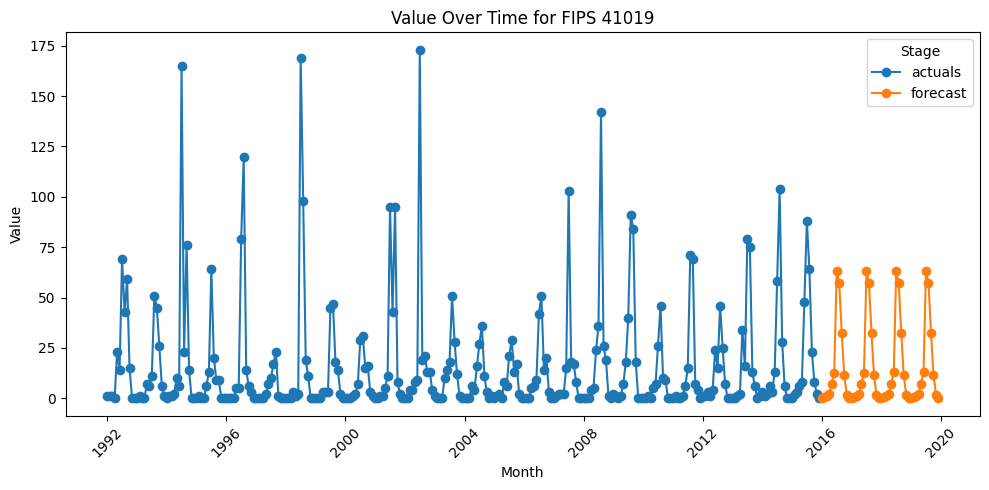

In [32]:
fips_code = "41019"
subset = combined_results[combined_results['FIPS'] == fips_code]

plt.figure(figsize=(10,5))

for stage, temp in subset.groupby("stage"):
    plt.plot(
        temp["MonthStart"], 
        temp["value"], 
        marker="o", 
        label=stage
    )

plt.title(f"Value Over Time for FIPS {fips_code}")
plt.xlabel("Month")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="Stage")
plt.tight_layout()
plt.show()


In [40]:
test = combined_results[combined_results['stage']=="forecast"]
test.to_csv('test.csv')